# Does the ASR encoder already know who is speaking?

The question, settled with a number instead of an argument: **can the hidden
states our ASR already computes replace a diarization model?** If they can,
speaker separation costs a matrix multiply on activations we paid for anyway. If
they cannot, Sortformer (236 MB) stays and we stop wondering.

Defaults to **parakeet-tdt-0.6b-v3**, the model Meeting Summary is actually
moving to (`bench/asr`), not to Whisper. Whisper is selectable for comparison,
since the two encoders are trained differently enough that the answer could
differ: parakeet is a FastConformer trained with a TDT objective, Whisper is an
attention encoder-decoder with an autoregressive LM on top.

### The free ground truth

A Piko recording holds two *physically separate* tracks — `mic.m4a` is you,
`system.m4a` is everyone else. That is a labelled dataset nobody annotated:
wherever the two tracks disagree loudly, the answer is known. Only segments with
a decisive level gap are scored, so the probe is measured against evidence rather
than against another model's opinion.

### The prior being tested

ASR training pushes *towards* speaker invariance — the same word from two voices
should land in the same place, so identity is nuisance variation the encoder is
rewarded for discarding. The expectation is that separability **falls** with
depth, which would make the last hidden state the worst possible tap point — and
the last hidden state is exactly what the shortcut would use. Measuring every
layer turns that from a claim into a curve.

### Running it

```bash
uv run --with jupyterlab --with matplotlib jupyter lab bench/speakers/encoder_speaker_probe.ipynb
```

**Privacy:** no cell prints transcript text — only timings, counts and scores.

## 1. Point it at a recording

In [1]:
from pathlib import Path

# A Piko recording folder: needs mic.m4a, system.m4a and meeting.m4a. An
# imported file has no side tracks, therefore no ground truth, and cannot be
# used here.
RECORDING = Path.home() / "Library/Application Support/Piko/Recordings" / "2026-07-27-102853"

ENGINE = "parakeet"  # or "whisper"
PARAKEET_MODEL = "mlx-community/parakeet-tdt-0.6b-v3"
WHISPER_MODEL = "mlx-community/whisper-large-v3-turbo"

# How far apart the two tracks must be (log10 units) before a segment is trusted
# as a label. 0.30 means one side is ~2x louder than the other.
TRUST_MARGIN = 0.30

assert RECORDING.is_dir(), f"no such recording folder: {RECORDING}"
print(RECORDING.name, "|", ENGINE)

2026-07-27-102853 | parakeet


## 2. Load the three tracks

Track lengths must agree to well under a second. Large drift means the segment
timestamps do not line up with the side tracks, and everything below would be
measuring that bug instead of the encoder.

In [2]:
import numpy as np
from piko.skills.meeting.audio import RAW_RATE, load_samples

mic = load_samples(RECORDING / "mic.m4a")
system = load_samples(RECORDING / "system.m4a")
mix = load_samples(RECORDING / "meeting.m4a")

for name, track in (("mic", mic), ("system", system), ("mix", mix)):
    print(f"{name:7s} {track.size / RAW_RATE:8.1f}s")

assert mic.size and system.size, "no side tracks — this recording has no ground truth"
drift = abs(mic.size - system.size) / RAW_RATE
print(f"\ntrack drift {drift:.3f}s" + ("   <-- too large, results are suspect" if drift > 0.5 else "   ok"))

mic       1237.1s
system    1237.0s
mix       1237.1s

track drift 0.064s   ok


## 3. Load the encoder

Both engines expose the same three things to this notebook: a function from audio
to *every* layer's states, the seconds-per-frame of those states, and how many
probe points there are.

- **parakeet** — FastConformer, 24 blocks, d=1024, subsampling x8 over a 10 ms hop,
  so one frame per **80 ms**. The layer capture is verified against the model's own
  `encoder()` output.
- **whisper** — 30 s windows into 1500 frames, one per **20 ms**; the extra final
  probe point is `ln_post`, the true 'last hidden state'.

In [3]:
import mlx.core as mx

if ENGINE == "parakeet":
    from mlx_audio.stt import load as load_stt
    from mlx_audio.stt.models.parakeet.audio import log_mel_spectrogram as parakeet_mel

    asr = load_stt(PARAKEET_MODEL)
    preprocess, encoder = asr.preprocessor_config, asr.encoder
    d_model = asr.encoder_config.d_model
    FRAME_SEC = asr.encoder_config.subsampling_factor * preprocess.hop_length / preprocess.sample_rate
    PROBE_NAMES = [str(i) for i in range(len(encoder.layers))]

    def layer_states(samples):
        """Every conformer block's output for one window: list of (frames, d)."""
        mel = parakeet_mel(mx.array(samples), preprocess)
        if mel.ndim == 2:
            mel = mel[None]
        x, _ = encoder.pre_encode(mel, mx.array([mel.shape[-2]]))
        pos_emb = None
        if encoder.pos_enc is not None:
            x, pos_emb = encoder.pos_enc(x, offset=0)
        states = []
        for layer in encoder.layers:
            x = layer(x, pos_emb=pos_emb, cache=None)
            mx.eval(x)
            states.append(np.array(x[0].astype(mx.float32)))
        return states

elif ENGINE == "whisper":
    import mlx.nn as nn
    from mlx_whisper.audio import N_FRAMES, pad_or_trim
    from mlx_whisper.audio import log_mel_spectrogram as whisper_mel
    from mlx_whisper.load_models import load_model

    asr = load_model(WHISPER_MODEL, dtype=mx.float16)
    encoder = asr.encoder
    d_model = asr.dims.n_audio_state
    FRAME_SEC = 0.02
    PROBE_NAMES = [str(i) for i in range(len(encoder.blocks))] + ["ln_post"]

    def layer_states(samples):
        mel = whisper_mel(mx.array(samples), n_mels=asr.dims.n_mels)
        mel = pad_or_trim(mel, N_FRAMES, axis=-2).astype(mx.float16)[None]
        x = nn.gelu(encoder.conv1(mel))
        x = nn.gelu(encoder.conv2(x))
        x = x + encoder._positional_embedding
        states = []
        for block in encoder.blocks:
            x, _, _ = block(x)
            mx.eval(x)
            states.append(np.array(x[0].astype(mx.float32)))
        states.append(np.array(encoder.ln_post(x)[0].astype(mx.float32)))
        return states

else:
    raise ValueError(ENGINE)

n_probes = len(PROBE_NAMES)
WINDOW_SEC = 30.0
print(f"{ENGINE}: {n_probes} probe points, d={d_model}, {FRAME_SEC * 1000:.0f} ms per frame")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

parakeet: 24 probe points, d=1024, 80 ms per frame


## 4. Segment the call

Segments are only *time spans* here — the probe measures the encoder, not the
transcriber, so which model drew the boundaries does not change what is being
tested. parakeet aligns its own sentences; whisper reuses Piko's on-disk cache, so
a recording already transcribed in the app costs nothing.

Chunking is mandatory on parakeet for anything long — it OOMs Metal on unchunked
30-minute audio (see `bench/asr`).

In [4]:
if ENGINE == "parakeet":
    aligned = asr.generate(mx.array(mix), chunk_duration=120.0, overlap_duration=15.0)
    raw_spans = [(s.start, s.end) for s in aligned.sentences]
else:
    from piko.commands.transcribe import transcribe_video

    data = transcribe_video(str(RECORDING / "meeting.m4a"), WHISPER_MODEL, None)
    raw_spans = [(float(s["start"]), float(s["end"])) for s in data["segments"]]

spans = np.array([(a, b) for a, b in raw_spans if b > a])
print(f"{len(spans)} segments, {spans[:, 1].max():.0f}s covered")

297 segments, 1224s covered


## 5. Labels from the two tracks

Per segment, the log-ratio of far-end level to microphone level, each normalised
by its own track's typical speech level. This is the production rule from
`speakers.py` minus the hysteresis: undecided segments are dropped rather than
inherited, because a label carried over from a neighbour is not evidence.

In [5]:
from piko.skills.meeting.speakers import _NOISE_FLOOR, _reference_level, _segment_rms

mic_ref = _reference_level(mic, RAW_RATE) or _NOISE_FLOOR
sys_ref = _reference_level(system, RAW_RATE) or _NOISE_FLOOR

scores = np.array([
    float(np.log10(
        (_segment_rms(system, a, b, RAW_RATE) / sys_ref + 1e-6)
        / (_segment_rms(mic, a, b, RAW_RATE) / mic_ref + 1e-6)
    ))
    for a, b in spans
])

trusted = np.abs(scores) >= TRUST_MARGIN
labels = (scores > 0).astype(int)  # 1 = far end, 0 = microphone

print(f"segments        {len(scores)}")
print(f"trusted labels  {trusted.sum()}  ({trusted.mean():.0%})")
print(f"  far end       {(labels[trusted] == 1).sum()}")
print(f"  microphone    {(labels[trusted] == 0).sum()}")
print(f"undecided       {(~trusted).sum()}  <- the hysteresis cases, dropped")

assert trusted.sum() >= 20, "too few decisive segments to score anything"
majority = max(labels[trusted].mean(), 1 - labels[trusted].mean())
print(f"\nmajority-class baseline: {majority:.1%}  <- any probe must beat this")

segments        297
trusted labels  289  (97%)
  far end       226
  microphone    63
undecided       8  <- the hysteresis cases, dropped

majority-class baseline: 78.2%  <- any probe must beat this


## 6. Pool every layer over every segment

The mix is walked in 30 s windows; each layer's frames are mean-pooled over the
segment they fall in, so a segment straddling a window boundary accumulates from
both. Only pooled vectors are kept — full activations would be tens of gigabytes
on a long call.

In [6]:
pooled = np.zeros((n_probes, len(spans), d_model), dtype=np.float32)
frames_seen = np.zeros(len(spans), dtype=np.int64)

window_samples = int(WINDOW_SEC * RAW_RATE)
n_windows = int(np.ceil(mix.size / window_samples))

for w in range(n_windows):
    offset = w * WINDOW_SEC
    chunk = mix[w * window_samples : (w + 1) * window_samples]
    if chunk.size < RAW_RATE // 2:  # a scrap shorter than half a second
        continue
    touching = np.where((spans[:, 1] > offset) & (spans[:, 0] < offset + WINDOW_SEC))[0]
    if touching.size == 0:
        continue

    states = layer_states(chunk)
    available = states[0].shape[0]
    for i in touching:
        first = int(max(0.0, spans[i, 0] - offset) / FRAME_SEC)
        last = min(int(min(WINDOW_SEC, spans[i, 1] - offset) / FRAME_SEC), available)
        if last <= first:
            continue
        for p in range(n_probes):
            pooled[p, i] += states[p][first:last].sum(axis=0)
        frames_seen[i] += last - first

    print(f"\rwindow {w + 1}/{n_windows}", end="")

usable = frames_seen > 0
pooled[:, usable] /= frames_seen[usable][None, :, None]
print(f"\npooled {usable.sum()} segments across {n_probes} probe points")

window 41/42
pooled 297 segments across 24 probe points


## 7. How separable are they, layer by layer?

Two scores, both dependency-free:

- **probe** — cosine-normalised nearest-centroid classification, 5-fold. The
  *generous* reading: it gets to see labels, and answers 'is the information in
  there at all'.
- **cluster** — 2-means with no labels, scored by its best matching to the truth.
  The honest reading, because a real diarizer has no labels either.

Clearing the majority baseline by a little is not a result. A replacement for
Sortformer has to win by a wide margin *in the cluster column*.

In [7]:
def normalise(X):
    return X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), 1e-9)


def nearest_centroid_cv(X, y, folds=5, seed=0):
    X = normalise(X)
    order = np.random.default_rng(seed).permutation(len(y))
    correct = 0
    for f in range(folds):
        test = order[f::folds]
        train = np.setdiff1d(order, test)
        if len(np.unique(y[train])) < 2:
            continue
        centroids = np.stack([
            normalise(X[train][y[train] == c].mean(axis=0)[None])[0] for c in (0, 1)
        ])
        correct += ((X[test] @ centroids.T).argmax(axis=1) == y[test]).sum()
    return correct / len(y)


def kmeans2(X, iters=60, seed=0):
    X = normalise(X)
    centroids = X[np.random.default_rng(seed).choice(len(X), size=2, replace=False)]
    assignment = np.zeros(len(X), dtype=int)
    for _ in range(iters):
        new = (X @ centroids.T).argmax(axis=1)
        if (new == assignment).all():
            break
        assignment = new
        for c in (0, 1):
            if (assignment == c).any():
                centroids[c] = normalise(X[assignment == c].mean(axis=0)[None])[0]
    return assignment


keep = trusted & usable
y = labels[keep]
print(f"scoring on {keep.sum()} labelled segments\n")

probe_scores, cluster_scores = [], []
for p in range(n_probes):
    X = pooled[p, keep]
    probe_scores.append(nearest_centroid_cv(X, y))
    a = kmeans2(X)
    cluster_scores.append(max((a == y).mean(), (a != y).mean()))

probe_scores = np.array(probe_scores)
cluster_scores = np.array(cluster_scores)

print(f"{'layer':>8}  {'probe':>7}  {'cluster':>8}")
for p in range(n_probes):
    tail = "  <- the shortcut" if p == n_probes - 1 else ""
    print(f"{PROBE_NAMES[p]:>8}  {probe_scores[p]:6.1%}  {cluster_scores[p]:7.1%}{tail}")

print(f"\nmajority baseline {majority:.1%}")
best = int(cluster_scores.argmax())
print(f"best layer by cluster: {PROBE_NAMES[best]} at {cluster_scores[best]:.1%}")

scoring on 289 labelled segments

   layer    probe   cluster
       0   77.9%    61.2%
       1   81.3%    57.1%
       2   85.5%    60.9%
       3   87.5%    58.5%
       4   88.2%    60.6%
       5   87.9%    56.4%
       6   88.2%    54.3%
       7   81.7%    57.4%
       8   79.9%    57.8%
       9   75.1%    60.9%
      10   74.4%    62.6%
      11   73.4%    61.9%
      12   72.3%    76.5%
      13   73.7%    76.8%
      14   73.0%    62.6%
      15   72.0%    76.8%
      16   70.9%    70.2%
      17   73.0%    71.6%
      18   71.3%    71.3%
      19   70.9%    73.0%
      20   72.3%    77.2%
      21   71.6%    71.3%
      22   74.7%    77.2%
      23   73.0%    66.8%  <- the shortcut

majority baseline 78.2%
best layer by cluster: 20 at 77.2%


## 8. The shape of the curve

If separability peaks early and decays towards the top, the invariance hypothesis
holds: 'take the last hidden state' is the worst available choice, while some
*earlier* layer might still be worth a head.

Matplotlib is building the font cache; this may take a moment.


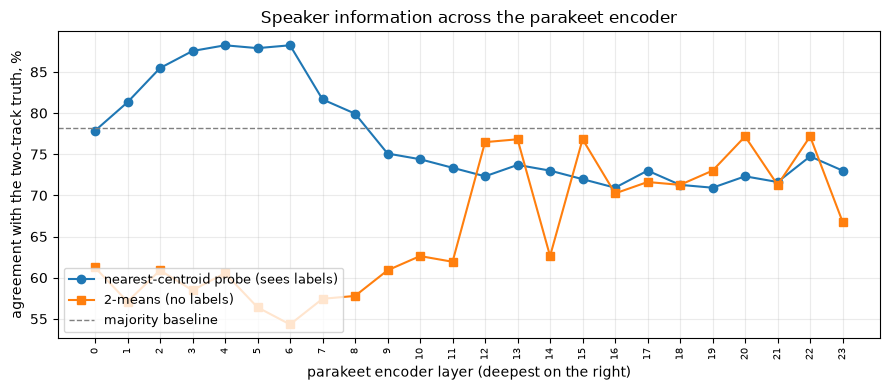

In [8]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("matplotlib not installed — rerun jupyter with --with matplotlib")

if plt is not None:
    fig, ax = plt.subplots(figsize=(9, 4))
    xs = np.arange(n_probes)
    ax.plot(xs, probe_scores * 100, marker="o", label="nearest-centroid probe (sees labels)")
    ax.plot(xs, cluster_scores * 100, marker="s", label="2-means (no labels)")
    ax.axhline(majority * 100, ls="--", lw=1, color="gray", label="majority baseline")
    ax.set_xticks(xs)
    ax.set_xticklabels(PROBE_NAMES, fontsize=7, rotation=90)
    ax.set_xlabel(f"{ENGINE} encoder layer (deepest on the right)")
    ax.set_ylabel("agreement with the two-track truth, %")
    ax.set_title(f"Speaker information across the {ENGINE} encoder")
    ax.legend(loc="lower left", fontsize=9)
    ax.grid(alpha=0.25)
    fig.tight_layout()

## 9. The baseline it has to beat

Sortformer on the same mix, scored the same way: its voices are mapped onto
me/them by whichever assignment agrees best. This is the number that decides
whether the embedding shortcut is worth building — not the probe column.

In [9]:
from piko.skills.meeting.diarize import diarize, renumber

turns = diarize(mix)
print(f"sortformer found {len(renumber(turns))} voices in {len(turns)} turns\n")

if turns:
    owner = np.full(len(spans), -1)
    for i, (start, end) in enumerate(spans):
        held = {}
        for turn in turns:
            overlap = min(end, turn.end) - max(start, turn.start)
            if overlap > 0:
                held[turn.speaker] = held.get(turn.speaker, 0.0) + overlap
        if held:
            owner[i] = max(held, key=held.get)

    resolved = keep & (owner >= 0)
    print(f"segments it placed: {resolved.sum()} of {keep.sum()} labelled")

    voices = sorted(set(owner[resolved].tolist()))
    agreement = 0.0
    for mask in range(1 << len(voices)):
        mapping = {v: (mask >> k) & 1 for k, v in enumerate(voices)}
        predicted = np.array([mapping[o] for o in owner[resolved]])
        agreement = max(agreement, (predicted == labels[resolved]).mean())

    print(f"\nsortformer agreement:  {agreement:.1%}")
    print(f"best {ENGINE} layer:  {cluster_scores[best]:.1%} (unsupervised)")
else:
    print("diarization returned nothing — nothing to compare against")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

sortformer found 4 voices in 297 turns

segments it placed: 288 of 289 labelled

sortformer agreement:  78.1%
best parakeet layer:  77.2% (unsupervised)


## How to read the result

- **cluster column sits near the majority baseline at every layer** — the encoder
  threw speaker identity away. The shortcut is dead; keep Sortformer.
- **cluster column rises early and falls towards the top** — the information
  survives low in the stack. A head on layer *k* becomes a real option, and 'last
  hidden state' was simply the wrong tap point.
- **cluster column beats Sortformer somewhere** — build it: no second model, no
  4-speaker ceiling, and clustering has no fixed cap on the number of voices.

Two caveats worth keeping in view.

This measures *me vs them* — a two-way split of two physically distinct channels,
the easiest possible version of the task. Telling three people apart **inside**
the far-end track is strictly harder, so read any score here as an optimistic
ceiling rather than the expected result.

And a good score would not be a finished feature: it says the information is
present, not that a rule exists to extract it. That still means a trained head,
which is a model — just ours, and without pretrained weights.